In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import warnings
warnings.filterwarnings("ignore")

In [13]:
AA_ORDER = "ACDEFGHIKLMNPQRSTVWY"

def aa_composition(seq, n=22):
    seq = seq[:n]
    if len(seq) == 0:
        return [0.0] * 20
    comp = ProteinAnalysis(seq).get_amino_acids_percent()
    return [comp.get(aa, 0.0) for aa in AA_ORDER]

def hydrophobicity_features(seq, window=5, n_region=40):
    seq = seq[:n_region]
    if len(seq) < window:
        return [-10.0, -10.0]
    kd_scale = {
        'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
        'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.5, 'I': 4.5,
        'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
        'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
    }
    scores = []
    for i in range(len(seq) - window + 1):
      window_seq = seq[i:i + window]
      score = np.mean([kd_scale.get(aa, 0) for aa in window_seq])
      scores.append(score)
    return [np.mean(scores), np.max(scores)]

def charge_features(seq, n=10):
    sub = seq[:n]
    pos = sub.count('K') + sub.count('R')
    neg = sub.count('D') + sub.count('E')
    return [pos, neg, pos - neg]

def extract_features(sequences):
    features = []
    for seq in sequences:
        comp = aa_composition(seq, n=22)
        hydro = hydrophobicity_features(seq, window=5, n_region=40)
        charge = charge_features(seq, n=10)
        features.append(comp + hydro + charge)
    return np.array(features)

In [14]:
df = pd.read_csv("../Data_Preparation/data.tsv", sep="\t")

# Validate required columns
assert 'Sequence' in df.columns, "Column 'Sequence' is missing!"
assert 'Label' in df.columns, "Column 'Label' is missing!"
assert 'Set' in df.columns, "Column 'Set' is missing!"
assert set(df['Label'].unique()) == {'Positive', 'Negative'}, "Labels must be 'Positive' or 'Negative'"

# Robust function to check if Set value is numeric
def is_numeric_set(val):
    if pd.isna(val):
        return False
    val_str = str(val).strip()
    if not val_str:
        return False
    try:
        float(val_str)
        return True
    except ValueError:
        return False

# Apply and split
df['is_numeric'] = df['Set'].apply(is_numeric_set)
df_cv = df[df['is_numeric']].copy()
df_benchmark = df[~df['is_numeric']].copy()

print(f"CV  {len(df_cv)} samples")
print(f"Benchmark  {len(df_benchmark)} samples")

# Debug: show unique Set values in CV data
if len(df_cv) > 0:
    print("Unique Set values in CV data:", sorted(df_cv['Set'].unique()))
else:
    raise ValueError("No numeric Set values found! Cannot proceed with 5-fold CV.")

# Convert Set to integer (0–4)
df_cv['Set'] = df_cv['Set'].astype(float).astype(int)

# Validate Set values
assert set(df_cv['Set'].unique()).issubset({0, 1, 2, 3, 4}), "CV Set values must be in {0,1,2,3,4}"

# Clean empty sequences
df_cv = df_cv[df_cv['Sequence'].str.len() > 0].reset_index(drop=True)
df_benchmark = df_benchmark[df_benchmark['Sequence'].str.len() > 0].reset_index(drop=True)

print(f"CV: {sum(df_cv['Label']=='Positive')} SP+, {sum(df_cv['Label']=='Negative')} SP-")
if len(df_benchmark) > 0:
    print(f"Benchmark: {sum(df_benchmark['Label']=='Positive')} SP+, {sum(df_benchmark['Label']=='Negative')} SP-")

CV  8021 samples
Benchmark  2006 samples
Unique Set values in CV data: ['0.0', '1.0', '2.0', '3.0', '4.0']
CV: 874 SP+, 7147 SP-
Benchmark: 219 SP+, 1787 SP-


In [15]:
feature_names = (
    [f"AA_{aa}" for aa in AA_ORDER] +
    ["Hydro_Mean", "Hydro_Max"] +
    ["Pos_Charge", "Neg_Charge", "Net_Charge"]
)

for i in range(5):
    test_set = i
    val_set = (i + 1) % 5
    train_sets = [s for s in range(5) if s != test_set and s != val_set]

    print("-" * 80)
    print(f"Fold {i+1}: Test={test_set}, Val={val_set}, Train={train_sets}")

    test_df = df_cv[df_cv['Set'] == test_set]
    val_df = df_cv[df_cv['Set'] == val_set]
    train_df = df_cv[df_cv['Set'].isin(train_sets)]

    # Skip if any split is empty
    if len(test_df) == 0 or len(val_df) == 0 or len(train_df) == 0:
        print(f"Warning: One of the splits is empty. Skipping fold {i+1}.")
        continue

    # Create target vectors
    y_train = train_df['Label'].map({'Positive': 1, 'Negative': 0}).values
    y_val = val_df['Label'].map({'Positive': 1, 'Negative': 0}).values
    y_test = test_df['Label'].map({'Positive': 1, 'Negative': 0}).values

    # Extract features
    X_train = extract_features(train_df['Sequence'])
    X_val = extract_features(val_df['Sequence'])
    X_test = extract_features(test_df['Sequence'])

    # Save to NPZ
    np.savez(f'training_features_{i+1}.npz', matrix=X_train, target=y_train)
    np.savez(f'validation_features_{i+1}.npz', matrix=X_val, target=y_val)
    np.savez(f'testing_features_{i+1}.npz', matrix=X_test, target=y_test)

print("\nNPZ files created successfully.")

--------------------------------------------------------------------------------
Fold 1: Test=0, Val=1, Train=[2, 3, 4]
--------------------------------------------------------------------------------
Fold 2: Test=1, Val=2, Train=[0, 3, 4]
--------------------------------------------------------------------------------
Fold 3: Test=2, Val=3, Train=[0, 1, 4]
--------------------------------------------------------------------------------
Fold 4: Test=3, Val=4, Train=[0, 1, 2]
--------------------------------------------------------------------------------
Fold 5: Test=4, Val=0, Train=[1, 2, 3]

NPZ files created successfully.


In [16]:
param_grids = [
    {'kernel': ['linear'], 'C': [0.5, 1, 2, 4]},
    {'kernel': ['rbf'], 'C': [1, 2, 4, 8], 'gamma': [0.5, 1, 2, 'scale']},
    {'kernel': ['poly'], 'C': [1, 2], 'degree': [2, 3], 'gamma': ['scale', 1], 'coef0': [0, 1]},
    {'kernel': ['sigmoid'], 'C': [1, 2, 4], 'gamma': ['scale', 1], 'coef0': [0, 1]}
]

results = []
conf_matrices = []
feature_counter = {}

print("\n Starting 5-fold nested CV with per-fold feature selection...")

for i in range(5):
    print(f"\n=== FOLD {i+1} ===")

    # Load data
    train_data = np.load(f'training_features_{i+1}.npz')
    val_data = np.load(f'validation_features_{i+1}.npz')
    test_data = np.load(f'testing_features_{i+1}.npz')

    X_train, y_train = train_data['matrix'], train_data['target']
    X_val, y_val = val_data['matrix'], val_data['target']
    X_test, y_test = test_data['matrix'], test_data['target']

    # Feature selection via RF on TRAIN only
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Find best k (3 to min(25, n_features))
    best_mcc_val = -1
    best_k = None
    best_subset = None

    max_k = min(25, X_train.shape[1])
    for k in range(3, max_k + 1):
        top_idx = np.argsort(rf.feature_importances_)[::-1][:k]
        X_tr_k = X_train[:, top_idx]
        X_va_k = X_val[:, top_idx]

        scaler = StandardScaler()
        X_tr_k_sc = scaler.fit_transform(X_tr_k)
        X_va_k_sc = scaler.transform(X_va_k)

        svm_temp = SVC(kernel='rbf', C=1, gamma='scale')
        svm_temp.fit(X_tr_k_sc, y_train)
        mcc_val = matthews_corrcoef(y_val, svm_temp.predict(X_va_k_sc))

        if mcc_val > best_mcc_val:
            best_mcc_val = mcc_val
            best_k = k
            best_subset = top_idx

    # Count selected features
    selected_names = np.array(feature_names)[best_subset]
    for feat in selected_names:
        feature_counter[feat] = feature_counter.get(feat, 0) + 1

    # Final grid search on selected features
    X_train_sel = X_train[:, best_subset]
    X_val_sel = X_val[:, best_subset]
    X_test_sel = X_test[:, best_subset]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_sel)
    X_val_sc = scaler.transform(X_val_sel)
    X_test_sc = scaler.transform(X_test_sel)

    best_score = -1
    best_params = None
    best_svm = None

    for param_grid in param_grids:
        svm = SVC()
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        grid = GridSearchCV(svm, param_grid, cv=inner_cv, scoring='matthews_corrcoef', n_jobs=-1)
        grid.fit(X_train_sc, y_train)

        val_mcc = matthews_corrcoef(y_val, grid.predict(X_val_sc))
        if val_mcc > best_score:
            best_score = val_mcc
            best_params = grid.best_params_
            best_svm = grid.best_estimator_

    # Test evaluation
    y_pred = best_svm.predict(X_test_sc)
    mcc = matthews_corrcoef(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Fold': i+1,
        'MCC': mcc,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Best_Params': best_params
    })
    conf_matrices.append(cm)

    print(f"Test MCC: {mcc:.4f} | Kernel: {best_params['kernel']} | Params: {best_params}")



 Starting 5-fold nested CV with per-fold feature selection...

=== FOLD 1 ===
Test MCC: 0.8037 | Kernel: rbf | Params: {'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}

=== FOLD 2 ===
Test MCC: 0.8011 | Kernel: linear | Params: {'C': 2, 'kernel': 'linear'}

=== FOLD 3 ===
Test MCC: 0.8076 | Kernel: rbf | Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

=== FOLD 4 ===
Test MCC: 0.8269 | Kernel: rbf | Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

=== FOLD 5 ===
Test MCC: 0.7817 | Kernel: rbf | Params: {'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}



✅ FINAL PERFORMANCE (5-FOLD NESTED CV)
MCC       : 0.8042 ± 0.0161
Accuracy  : 0.9615 ± 0.0032
Precision : 0.8156 ± 0.0235
Recall    : 0.8364 ± 0.0256

Average Confusion Matrix:
[[1396   33]
 [  28  146]]

Most selected kernels: {'rbf': 4, 'linear': 1}

✅ Features selected in ≥4 folds (22):
[np.str_('Hydro_Max'), np.str_('Hydro_Mean'), np.str_('AA_L'), np.str_('Neg_Charge'), np.str_('AA_A'), np.str_('AA_R'), np.str_('Net_Charge'), np.str_('AA_F'), np.str_('AA_V'), np.str_('AA_N'), np.str_('AA_S'), np.str_('AA_G'), np.str_('AA_E'), np.str_('AA_K'), np.str_('AA_I'), np.str_('AA_P'), np.str_('AA_C'), np.str_('Pos_Charge'), np.str_('AA_W'), np.str_('AA_D'), np.str_('AA_T'), np.str_('AA_Q')]


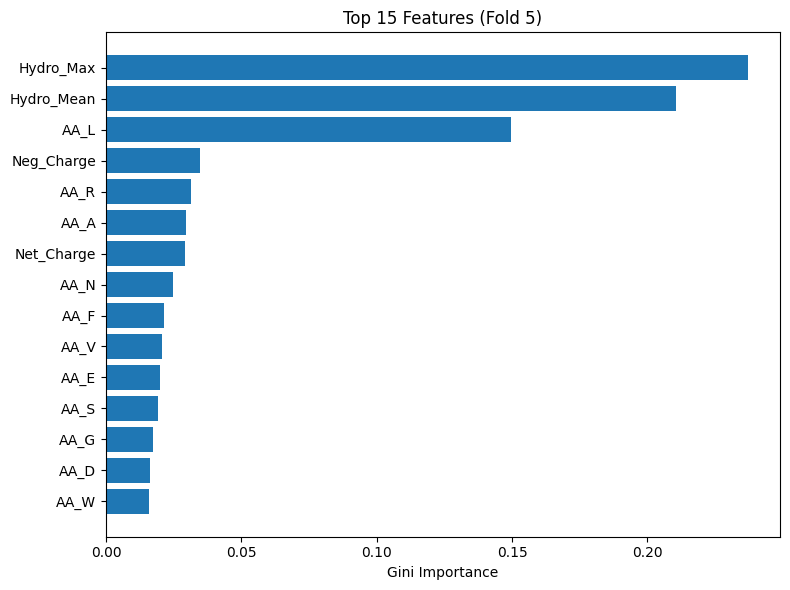

In [17]:
res_df = pd.DataFrame(results)
print("\n" + "="*70)
print("✅ FINAL PERFORMANCE (5-FOLD NESTED CV)")
print("="*70)
for col in ['MCC', 'Accuracy', 'Precision', 'Recall']:
    mean_val = res_df[col].mean()
    std_val = res_df[col].std()
    print(f"{col:10}: {mean_val:.4f} ± {std_val:.4f}")

avg_cm = np.mean(conf_matrices, axis=0).astype(int)
print("\nAverage Confusion Matrix:")
print(avg_cm)

kernels = [r['Best_Params']['kernel'] for r in results]
print(f"\nMost selected kernels: {pd.Series(kernels).value_counts().to_dict()}")

stable_features = [f for f, c in feature_counter.items() if c >= 4]
print(f"\n✅ Features selected in ≥4 folds ({len(stable_features)}):")
print(stable_features)

# Plot feature importances (last fold)
import matplotlib.pyplot as plt
rf_plot = RandomForestClassifier(n_estimators=200, random_state=42)
rf_plot.fit(X_train, y_train)
imp = pd.Series(rf_plot.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
plt.barh(imp.head(15).index[::-1], imp.head(15).values[::-1])
plt.xlabel("Gini Importance")
plt.title("Top 15 Features (Fold 5)")
plt.tight_layout()
plt.show()